In [1]:
# ============================================================
# 1. Setup and Imports
# ============================================================
# Objective:
# Initialize the environment and import required libraries for
# data exploration and visualization.
#
# Notes:
# - This notebook is strictly for EDA (no modeling).
# - Focus is on understanding data quality and household behavior.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# ============================================================
# 2. Load Raw Dataset
# ============================================================
# Objective:
# Load the raw household smart meter dataset and prepare the
# timestamp index.
#
# Key points:
# - Dataset contains cumulative meter readings.
# - Timestamp column may differ across versions.
# - All timestamps are converted to UTC.
# ============================================================

data_path = Path("../data/household_data_15min_singleindex.csv")

df_raw = pd.read_csv(data_path)

timestamp_col = "cet_cest_timestamp" if "cet_cest_timestamp" in df_raw.columns else "utc_timestamp"

df_raw[timestamp_col] = pd.to_datetime(df_raw[timestamp_col], utc=True)

df = df_raw.sort_values(timestamp_col).set_index(timestamp_col)

print("Shape:", df.shape)
df.head()

Shape: (153810, 70)


,utc_timestamp,DE_KN_industrial1_grid_import,DE_KN_industrial1_pv_1,DE_KN_industrial1_pv_2,DE_KN_industrial2_grid_import,DE_KN_industrial2_pv,DE_KN_industrial2_storage_charge,DE_KN_industrial2_storage_decharge,DE_KN_industrial3_area_offices,DE_KN_industrial3_area_room_1,...,DE_KN_residential5_refrigerator,DE_KN_residential5_washing_machine,DE_KN_residential6_circulation_pump,DE_KN_residential6_dishwasher,DE_KN_residential6_freezer,DE_KN_residential6_grid_export,DE_KN_residential6_grid_import,DE_KN_residential6_pv,DE_KN_residential6_washing_machine,interpolated
cet_cest_timestamp,,,,,,,,,,,,,,,,,,,,,
2014-12-11 17:45:00+00:00,2014-12-11T17:45:00Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 18:00:00+00:00,2014-12-11T18:00:00Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 18:15:00+00:00,2014-12-11T18:15:00Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 18:30:00+00:00,2014-12-11T18:30:00Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2014-12-11 18:45:00+00:00,2014-12-11T18:45:00Z,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
# ============================================================
# 3. Household Signal Overview
# ============================================================
# Objective:
# Inspect available signals for each household and assess data
# completeness.
#
# Why this matters:
# - Not all households have the same sensors (PV, EV, etc.).
# - Missing data can heavily impact forecasting quality.
# ============================================================

residential_ids = [1, 2, 3, 4, 5, 6]

overview_rows = []

for house_id in residential_ids:
    prefix = f"DE_KN_residential{house_id}_"

    # expected key household energy management signals
    grid_import_col = f"{prefix}grid_import"
    grid_export_col = f"{prefix}grid_export"
    pv_col = f"{prefix}pv"
    ev_col = f"{prefix}ev"
    heat_pump_col = f"{prefix}heat_pump"

    # all columns belonging to this household
    house_cols = [c for c in df.columns if c.startswith(prefix)]

    if len(house_cols) > 0:
        total_cells = df[house_cols].shape[0] * df[house_cols].shape[1]
        missing_cells = df[house_cols].isna().sum().sum()
        missing_percent = 100 * missing_cells / total_cells
        non_null_rows = df[house_cols].dropna(how="all").shape[0]
    else:
        missing_percent = np.nan
        non_null_rows = 0

    overview_rows.append({
        "household": f"residential{house_id}",
        "n_columns": len(house_cols),
        "grid_import": grid_import_col in df.columns,
        "grid_export": grid_export_col in df.columns,
        "pv": pv_col in df.columns,
        "ev": ev_col in df.columns,
        "heat_pump": heat_pump_col in df.columns,
        "non_null_rows": non_null_rows,
        "missing_percent_all_house_cols": round(missing_percent, 2) if not np.isnan(missing_percent) else np.nan,
        "columns": ", ".join(house_cols)
    })

overview_df = pd.DataFrame(overview_rows)

def hems_note(row):
    if row["ev"] and row["pv"] and row["grid_import"] and row["grid_export"]:
        return "very strong HEMS case"
    elif row["pv"] and row["grid_import"] and row["grid_export"]:
        return "strong solar/grid case"
    elif row["pv"] and row["grid_import"]:
        return "baseline solar case"
    elif row["grid_import"]:
        return "limited case"
    else:
        return "weak case"

overview_df["hems_note"] = overview_df.apply(hems_note, axis=1)

display(overview_df[[
    "household",
    "n_columns",
    "grid_import",
    "grid_export",
    "pv",
    "ev",
    "heat_pump",
    "non_null_rows",
    "missing_percent_all_house_cols",
    "hems_note"
]])

,household,n_columns,grid_import,grid_export,pv,ev,heat_pump,non_null_rows,missing_percent_all_house_cols,hems_note
0,residential1,6,True,False,True,False,True,63487,60.04,baseline solar case
1,residential2,5,True,False,False,False,False,99792,53.33,limited case
2,residential3,8,True,True,True,False,False,132840,33.78,strong solar/grid case
3,residential4,9,True,True,True,True,True,81435,56.77,very strong HEMS case
4,residential5,4,True,False,False,False,False,123211,39.90,limited case
5,residential6,7,True,True,True,False,False,86137,53.38,strong solar/grid case


In [4]:
# ------------------------------------------------------------
# 4. Build Interval-Based Energy Master Table
# ------------------------------------------------------------
def compute_interval(series):
    """
    Convert cumulative meter readings to interval values.
    Negative diffs are clipped to zero.
    """
    return series.diff().clip(lower=0)


houses = [1, 2, 3, 4, 5, 6]
master_rows = []

for h in houses:
    prefix = f"DE_KN_residential{h}_"

    def get_col(col_name):
        full_col = prefix + col_name
        if full_col in df.columns:
            return compute_interval(df[full_col])
        else:
            return pd.Series(0.0, index=df.index)

    grid_import = get_col("grid_import")
    grid_export = get_col("grid_export")
    pv = get_col("pv")

    washing_machine = get_col("washing_machine")
    dishwasher = get_col("dishwasher")
    refrigerator = get_col("refrigerator")
    freezer = get_col("freezer")
    circulation_pump = get_col("circulation_pump")
    heat_pump = get_col("heat_pump")
    ev = get_col("ev")

    # load definition
    load = (grid_import + pv - grid_export).clip(lower=0)

    temp_df = pd.DataFrame({
        "timestamp": df.index,
        "household": f"residential{h}",
        "grid_import_kwh_15m": grid_import,
        "grid_export_kwh_15m": grid_export,
        "pv_kwh_15m": pv,
        "load_kwh_15m": load,
        "washing_machine_kwh_15m": washing_machine,
        "dishwasher_kwh_15m": dishwasher,
        "refrigerator_kwh_15m": refrigerator,
        "freezer_kwh_15m": freezer,
        "circulation_pump_kwh_15m": circulation_pump,
        "heat_pump_kwh_15m": heat_pump,
        "ev_kwh_15m": ev,
    })

    temp_df = temp_df.dropna(subset=["timestamp"]).copy()
    master_rows.append(temp_df)

energy_master_df = pd.concat(master_rows, ignore_index=True)

print("Energy master table shape:", energy_master_df.shape)
display(energy_master_df.head())

Energy master table shape: (922860, 13)


,timestamp,household,grid_import_kwh_15m,grid_export_kwh_15m,pv_kwh_15m,load_kwh_15m,washing_machine_kwh_15m,dishwasher_kwh_15m,refrigerator_kwh_15m,freezer_kwh_15m,circulation_pump_kwh_15m,heat_pump_kwh_15m,ev_kwh_15m
0,2014-12-11 17:45:00+00:00,residential1,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,0.0
1,2014-12-11 18:00:00+00:00,residential1,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,0.0
2,2014-12-11 18:15:00+00:00,residential1,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,0.0
3,2014-12-11 18:30:00+00:00,residential1,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,0.0
4,2014-12-11 18:45:00+00:00,residential1,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,0.0,NaN,0.0


In [5]:
# ------------------------------------------------------------
# 5. Household Energy Summary (Numerical Comparison)
# ------------------------------------------------------------

summary_rows = []

for household, g in energy_master_df.groupby("household"):

    total_import = g["grid_import_kwh_15m"].sum()
    total_export = g["grid_export_kwh_15m"].sum()
    total_pv = g["pv_kwh_15m"].sum()
    total_load = g["load_kwh_15m"].sum()

    total_washing_machine = g["washing_machine_kwh_15m"].sum()
    total_dishwasher = g["dishwasher_kwh_15m"].sum()
    total_refrigerator = g["refrigerator_kwh_15m"].sum()
    total_freezer = g["freezer_kwh_15m"].sum()
    total_circulation_pump = g["circulation_pump_kwh_15m"].sum()
    total_heat_pump = g["heat_pump_kwh_15m"].sum()
    total_ev = g["ev_kwh_15m"].sum()

    appliance_total = (
        total_washing_machine +
        total_dishwasher +
        total_refrigerator +
        total_freezer +
        total_circulation_pump +
        total_heat_pump +
        total_ev
    )

    appliance_ratio = appliance_total / total_load if total_load > 0 else np.nan
    pv_self_consumption_ratio = (
        (total_pv - total_export) / total_pv if total_pv > 0 else np.nan
    )

    summary_rows.append({
        "household": household,

        "total_load_kwh": round(total_load, 2),
        "total_import_kwh": round(total_import, 2),
        "total_export_kwh": round(total_export, 2),
        "total_pv_kwh": round(total_pv, 2),

        "appliance_total_kwh": round(appliance_total, 2),
        "appliance_to_load_ratio": round(appliance_ratio, 3) if not np.isnan(appliance_ratio) else np.nan,

        "pv_self_consumption_ratio": round(pv_self_consumption_ratio, 3) if not np.isnan(pv_self_consumption_ratio) else np.nan,

        "ev_kwh": round(total_ev, 2),
        "heat_pump_kwh": round(total_heat_pump, 2),
    })

household_summary_df = pd.DataFrame(summary_rows).sort_values("total_load_kwh", ascending=False)

display(household_summary_df)

,household,total_load_kwh,total_import_kwh,total_export_kwh,total_pv_kwh,appliance_total_kwh,appliance_to_load_ratio,pv_self_consumption_ratio,ev_kwh,heat_pump_kwh
0,residential1,25618.16,9096.36,0.00,16521.80,11235.20,0.439,1.000,0.00,10213.52
5,residential6,18198.15,7348.30,3443.15,20495.40,1272.12,0.070,0.832,0.00,0.00
3,residential4,15902.97,10247.07,19070.75,24576.44,7802.16,0.491,0.224,2225.03,4728.82
4,residential5,8773.78,8773.78,0.00,0.00,1695.74,0.193,NaN,0.00,0.00
2,residential3,8378.97,5778.08,9388.80,13673.66,5751.44,0.686,0.313,0.00,0.00
1,residential2,4495.45,4495.45,0.00,0.00,2033.76,0.452,NaN,0.00,0.00


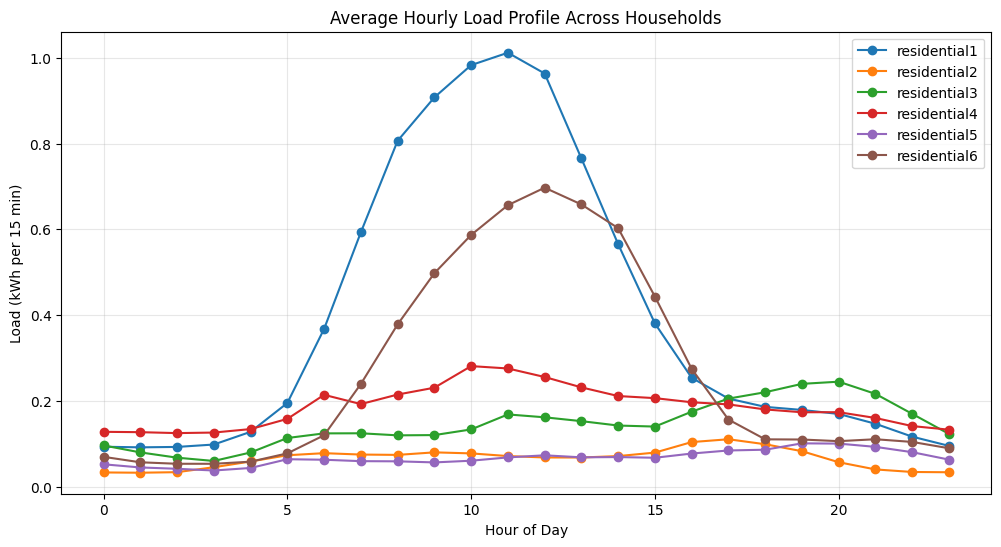

In [6]:
# ------------------------------------------------------------
# 6. Average Hourly Load Profile (All Households)
# ------------------------------------------------------------

eda_df = energy_master_df.copy()

# ensure timestamp is datetime
eda_df["timestamp"] = pd.to_datetime(eda_df["timestamp"], utc=True)

# extract hour
eda_df["hour"] = eda_df["timestamp"].dt.hour

# --------------------------------------------
# remove extreme outliers (per household)
# --------------------------------------------
q99 = eda_df.groupby("household")["load_kwh_15m"].quantile(0.99).to_dict()

eda_df["q99"] = eda_df["household"].map(q99)

eda_df_clean = eda_df[eda_df["load_kwh_15m"] <= eda_df["q99"]].copy()

# --------------------------------------------
# compute hourly average
# --------------------------------------------
hourly_profile_df = (
    eda_df_clean
    .groupby(["household", "hour"], as_index=False)["load_kwh_15m"]
    .mean()
)

# --------------------------------------------
# plot
# --------------------------------------------
plt.figure(figsize=(12, 6))

for household in sorted(hourly_profile_df["household"].unique()):
    
    temp = hourly_profile_df[hourly_profile_df["household"] == household]
    
    plt.plot(
        temp["hour"],
        temp["load_kwh_15m"],
        marker="o",
        label=household
    )

plt.title("Average Hourly Load Profile Across Households")
plt.xlabel("Hour of Day")
plt.ylabel("Load (kWh per 15 min)")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

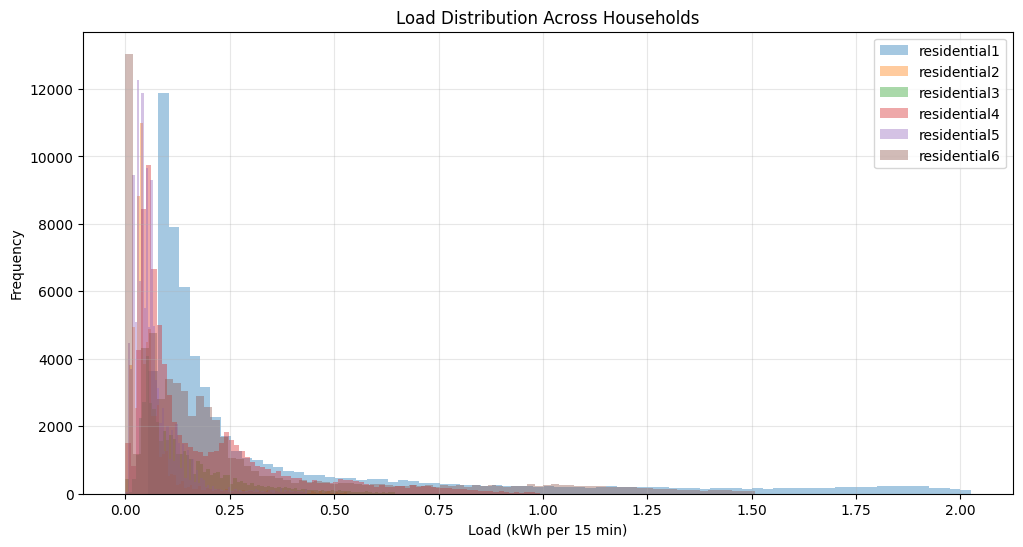

In [7]:
# ------------------------------------------------------------
# 7. Load Distribution Across Households
# ------------------------------------------------------------

# reuse cleaned EDA dataframe (with outliers removed)
dist_df = eda_df_clean.copy()

plt.figure(figsize=(12, 6))

for household in sorted(dist_df["household"].unique()):

    subset = dist_df[dist_df["household"] == household]

    plt.hist(
        subset["load_kwh_15m"],
        bins=80,
        alpha=0.4,
        label=household
    )

plt.title("Load Distribution Across Households")
plt.xlabel("Load (kWh per 15 min)")
plt.ylabel("Frequency")

plt.legend()
plt.grid(alpha=0.3)

plt.show()

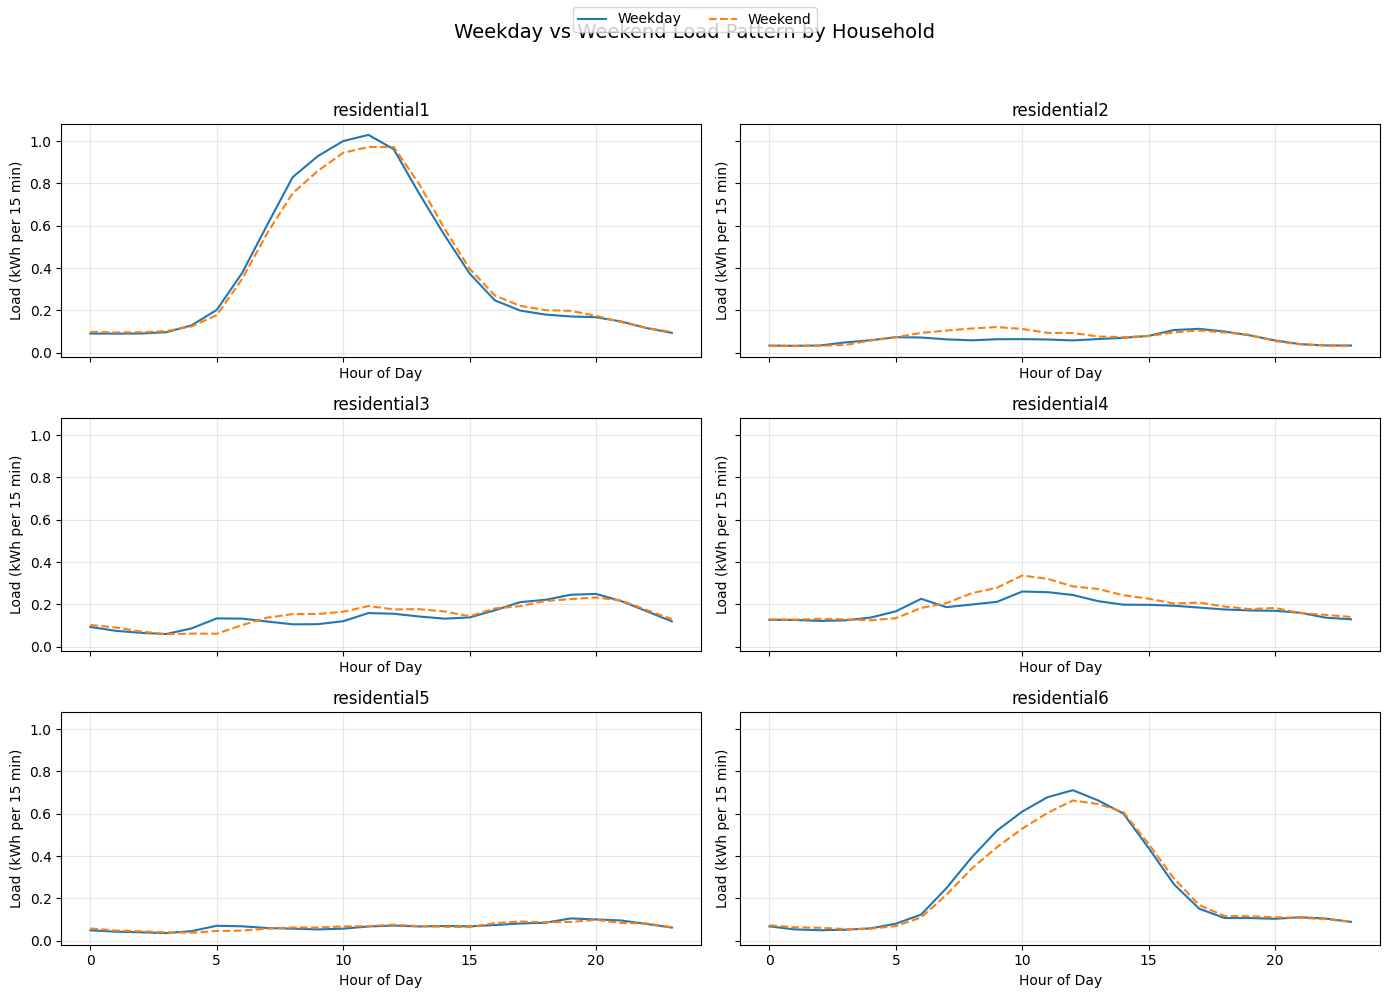

In [8]:
# ------------------------------------------------------------
# 8. Weekday vs Weekend Load Pattern (Per Household)
# ------------------------------------------------------------

week_df = energy_master_df.copy()

# ensure timestamp format
week_df["timestamp"] = pd.to_datetime(week_df["timestamp"], utc=True)

# calendar features
week_df["hour"] = week_df["timestamp"].dt.hour
week_df["day_of_week"] = week_df["timestamp"].dt.dayofweek
week_df["is_weekend"] = week_df["day_of_week"] >= 5

# remove extreme outliers per household
q99 = week_df.groupby("household")["load_kwh_15m"].quantile(0.99).to_dict()
week_df["q99"] = week_df["household"].map(q99)

week_df_clean = week_df[week_df["load_kwh_15m"] <= week_df["q99"]].copy()

# build weekday and weekend hourly profiles
weekday_profile = (
    week_df_clean[week_df_clean["is_weekend"] == False]
    .groupby(["household", "hour"], as_index=False)["load_kwh_15m"]
    .mean()
)

weekend_profile = (
    week_df_clean[week_df_clean["is_weekend"] == True]
    .groupby(["household", "hour"], as_index=False)["load_kwh_15m"]
    .mean()
)

households = sorted(week_df_clean["household"].unique())

fig, axes = plt.subplots(3, 2, figsize=(14, 10), sharex=True, sharey=True)
axes = axes.flatten()

for i, h in enumerate(households):
    ax = axes[i]

    wday = weekday_profile[weekday_profile["household"] == h]
    wend = weekend_profile[weekend_profile["household"] == h]

    ax.plot(
        wday["hour"],
        wday["load_kwh_15m"],
        label="Weekday"
    )

    ax.plot(
        wend["hour"],
        wend["load_kwh_15m"],
        linestyle="--",
        label="Weekend"
    )

    ax.set_title(h)
    ax.set_xlabel("Hour of Day")
    ax.set_ylabel("Load (kWh per 15 min)")
    ax.grid(alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2)

fig.suptitle("Weekday vs Weekend Load Pattern by Household", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

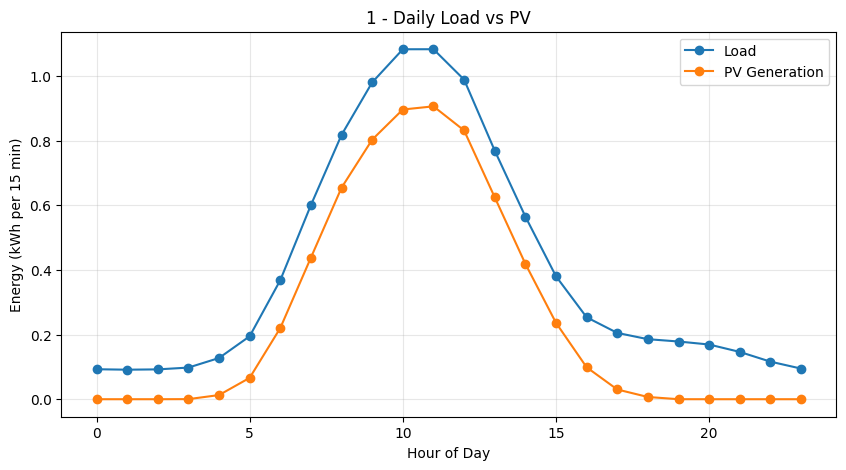

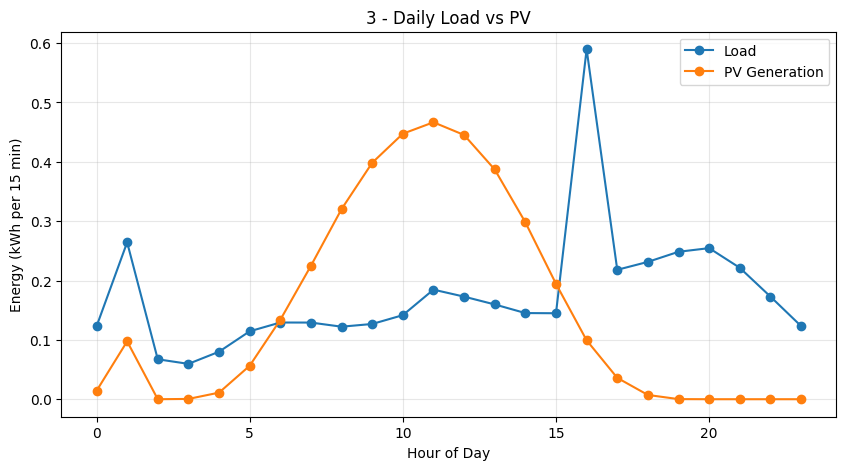

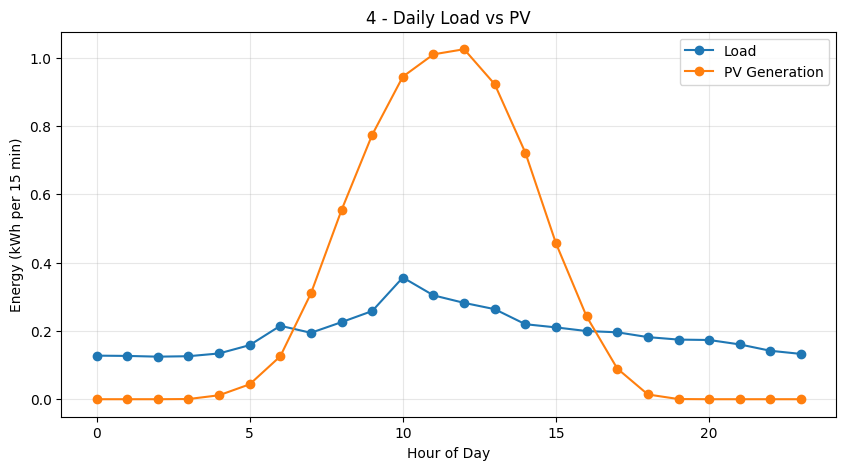

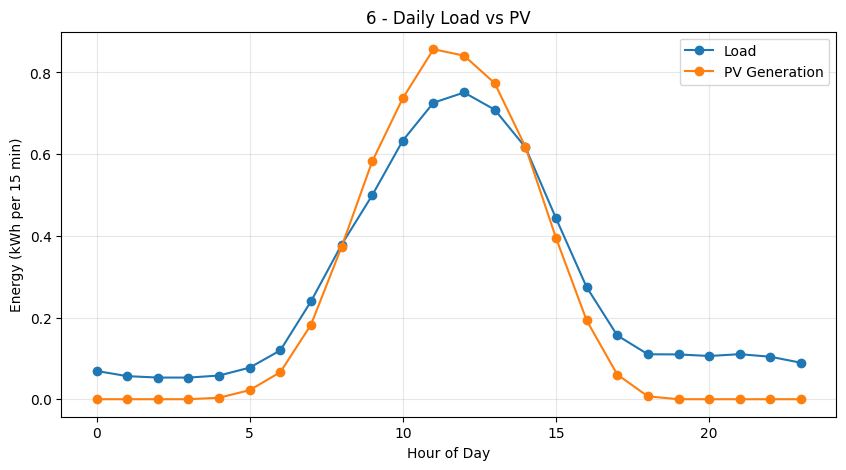

In [9]:
# ------------------------------------------------------------
# 9. Daily Load vs PV Generation (PV Households)
# ------------------------------------------------------------

pv_houses = [1, 3, 4, 6]

for h in pv_houses:

    load_col = "load_kwh_15m"
    pv_col = "pv_kwh_15m"

    temp = energy_master_df[
        energy_master_df["household"] == f"residential{h}"
    ].copy()

    temp["timestamp"] = pd.to_datetime(temp["timestamp"], utc=True)
    temp["hour"] = temp["timestamp"].dt.hour

    # aggregate hourly averages
    hourly_profile = (
        temp.groupby("hour")[[load_col, pv_col]]
        .mean()
        .reset_index()
    )

    plt.figure(figsize=(10, 5))

    plt.plot(
        hourly_profile["hour"],
        hourly_profile[load_col],
        marker="o",
        label="Load"
    )

    plt.plot(
        hourly_profile["hour"],
        hourly_profile[pv_col],
        marker="o",
        label="PV Generation"
    )

    plt.title(f"{h} - Daily Load vs PV")
    plt.xlabel("Hour of Day")
    plt.ylabel("Energy (kWh per 15 min)")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

,household,load_scale,pattern_clarity,simplicity,hems_relevance,total_score
0,residential2,1,2,4,1,8
1,residential5,2,2,4,1,9
2,residential3,2,3,3,3,11
3,residential4,3,3,2,5,13
4,residential6,4,4,3,4,15
5,residential1,5,5,5,4,19


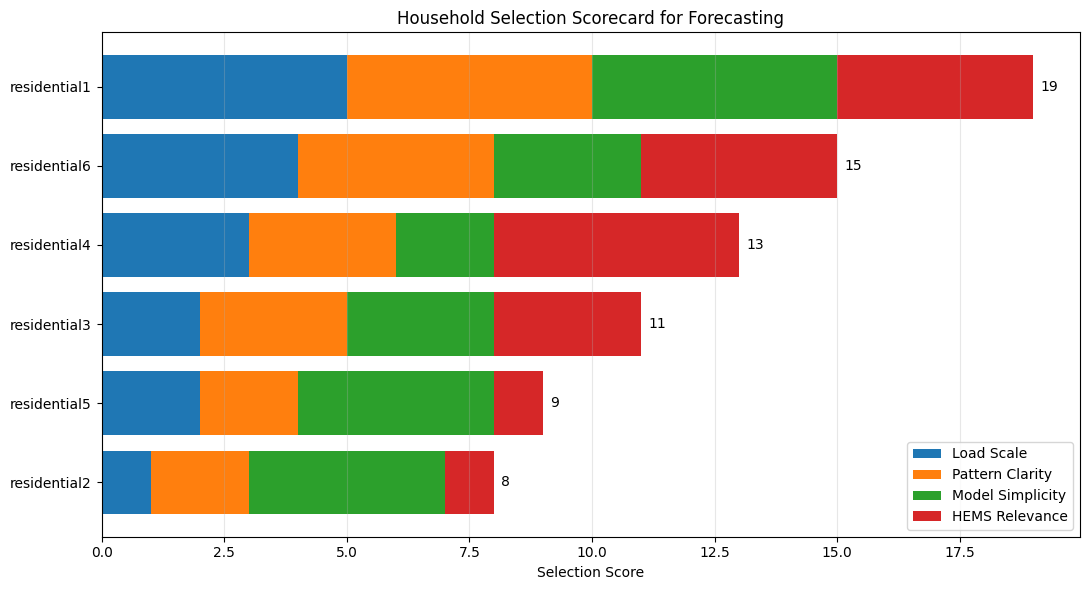

In [10]:
# ============================================================
# 10. Household Selection Scorecard
# ============================================================
# Objective:
# Create a presentation-friendly visual summary to justify why
# residential1 is selected as the best candidate for forecasting.
#
# Logic:
# Scores are assigned from EDA findings across four dimensions:
# 1. Load scale
# 2. Pattern clarity
# 3. Modeling simplicity
# 4. HEMS relevance
# ============================================================

scorecard_df = pd.DataFrame({
    "household": [
        "residential1",
        "residential2",
        "residential3",
        "residential4",
        "residential5",
        "residential6",
    ],
    "load_scale":      [5, 1, 2, 3, 2, 4],
    "pattern_clarity": [5, 2, 3, 3, 2, 4],
    "simplicity":      [5, 4, 3, 2, 4, 3],
    "hems_relevance":  [4, 1, 3, 5, 1, 4],
})

scorecard_df["total_score"] = scorecard_df[
    ["load_scale", "pattern_clarity", "simplicity", "hems_relevance"]
].sum(axis=1)

scorecard_df = scorecard_df.sort_values("total_score", ascending=True).reset_index(drop=True)

display(scorecard_df)

# -----------------------------
# Plot
# -----------------------------
fig, ax = plt.subplots(figsize=(11, 6))

households = scorecard_df["household"]
y_pos = np.arange(len(households))

load_scale = scorecard_df["load_scale"]
pattern_clarity = scorecard_df["pattern_clarity"]
simplicity = scorecard_df["simplicity"]
hems_relevance = scorecard_df["hems_relevance"]

ax.barh(y_pos, load_scale, label="Load Scale")
ax.barh(y_pos, pattern_clarity, left=load_scale, label="Pattern Clarity")
ax.barh(y_pos, simplicity, left=load_scale + pattern_clarity, label="Model Simplicity")
ax.barh(
    y_pos,
    hems_relevance,
    left=load_scale + pattern_clarity + simplicity,
    label="HEMS Relevance"
)

ax.set_yticks(y_pos)
ax.set_yticklabels(households)
ax.set_xlabel("Selection Score")
ax.set_title("Household Selection Scorecard for Forecasting")
ax.grid(axis="x", alpha=0.3)
ax.legend(loc="lower right")

# annotate total score
for i, total in enumerate(scorecard_df["total_score"]):
    ax.text(total + 0.15, i, str(total), va="center")

plt.tight_layout()
plt.show()

### 📊 Scorecard Explanation

Each household is evaluated across four dimensions derived from EDA:

- **Load Scale**  
  Represents total energy consumption. Higher values indicate stronger signal and better learnability for forecasting models.

- **Pattern Clarity**  
  Measures how clear and stable the daily load profile is (e.g., consistent peaks and smooth trends).

- **Model Simplicity**  
  Reflects system complexity. Households without export, EV, or highly irregular behavior score higher (easier to model).

- **HEMS Relevance**  
  Captures the presence of meaningful energy components (e.g., PV, heat pump) that make the scenario realistic and valuable.

---

### 🧠 Scoring Approach

Scores range from **1 (weak)** to **5 (strong)** and are assigned based on:
- Summary statistics (total load, ratios)
- Load profile visualizations
- Presence of energy systems (PV, EV, etc.)

---

### 🎯 Interpretation

Higher total score ⇒ better candidate for forecasting

➡️ `residential1` achieves the best balance between:
- strong signal,
- clear patterns,
- manageable complexity,
- and realistic energy behavior.